# Caso: Crédito Hipotecario
En este caso se trabaja con un conjunto de datos de crédito hipotecario el cuál se usará para mostrar el uso de LLM para la generación de nuevas variables.

# SECCIÓN 1: PRED DEFAULT EN BANCA

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

from sklearn.preprocessing import LabelEncoder

import gc
from sklearn.model_selection import KFold, StratifiedKFold
from lightgbm import LGBMClassifier, log_evaluation, early_stopping
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    brier_score_loss, log_loss, confusion_matrix, classification_report
)

# Importando datos

In [24]:
root_path = os.getcwd()
print(f"Current working directory: {root_path}")

Current working directory: c:\Users\Nitvn\Documentos\Dev\ai-applications-in-industry\scoring-fraud-detection


In [25]:
df = pd.read_csv(root_path + "/data/data_f.csv", encoding="utf-8")

In [26]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_OVERDUE_mean,AMT_CREDIT_SUM_OVERDUE_sum,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_DEBT_sum,CREDIT_ACTIVE_<lambda>,CREDIT_DAY_OVERDUE_max,AMT_ANNUITY_mean,AMT_ANNUITY_sum,DAYS_CREDIT_mean,DAYS_CREDIT_min,DAYS_CREDIT_max,CREDIT_TYPE_nunique,SK_ID_PREV_x,NAME_CONTRACT_STATUS,AMT_APPLICATION,AMT_CREDIT_y,INST_CNT,INST_PAY_DIFF_MEAN,INST_PAY_DIFF_MIN,INST_PAY_DIFF_MAX,INST_DELAY_MEAN,INST_DELAY_MAX,INST_TOTAL_PAID,INST_TOTAL_DUE,SK_ID_PREV_y,SK_DPD_x,AMT_BALANCE,SK_DPD_y
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,108131.945625,865055.565,0.0,0.0,49156.2,245781.0,2.0,0.0,0.0,0.0,-874.00,-1437.0,-103.0,2.0,1.0,1.0,179055.00,179055.00,19.0,0.000000,0.000,0.0,-20.421053,-12.0,219625.695,219625.695,1.0,0.0,NaN,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0

In [27]:
df.shape

(307511, 152)

In [28]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT_x', 'AMT_ANNUITY',
       ...
       'INST_PAY_DIFF_MIN', 'INST_PAY_DIFF_MAX', 'INST_DELAY_MEAN',
       'INST_DELAY_MAX', 'INST_TOTAL_PAID', 'INST_TOTAL_DUE', 'SK_ID_PREV_y',
       'SK_DPD_x', 'AMT_BALANCE', 'SK_DPD_y'],
      dtype='str', length=152)

# EDA y limpieza de datos

# Distribución de la variable Target

   labels  values
0       0  282686
1       1   24825


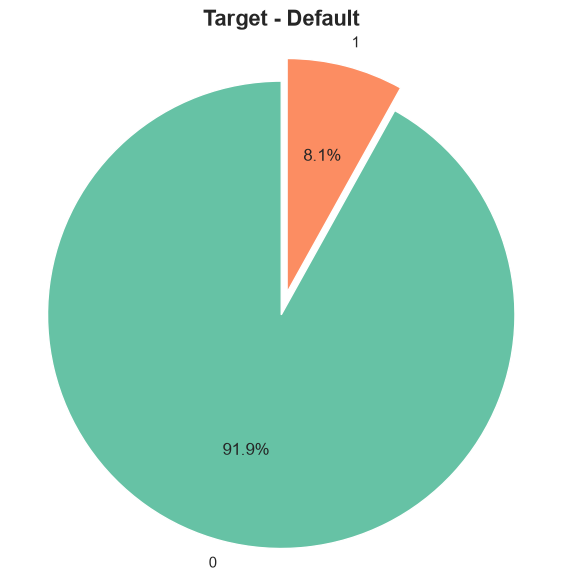

In [29]:
# La data esta desbalanceada
temp = df["TARGET"].value_counts()
data = pd.DataFrame({'labels': temp.index, 'values': temp.values})
print(data)
colors = sns.color_palette("Set2", n_colors=len(data))

plt.figure(figsize=(7, 7))
plt.pie(data['values'], labels=data['labels'], autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.1, 0))

plt.title('Target - Default', fontsize=16, weight='bold')

plt.axis('equal')
plt.show()

In [30]:
# @title
# Top 20 columns by missing %
missing = (df.isna().sum() / len(df) * 100).sort_values(ascending=False).head(20)
print("\nTop 10 columns by missing %:")
print(missing.round(3).to_string())


Top 10 columns by missing %:
AMT_ANNUITY_mean            73.982
SK_DPD_y                    71.739
AMT_BALANCE                 71.739
COMMONAREA_AVG              69.872
COMMONAREA_MODE             69.872
COMMONAREA_MEDI             69.872
NONLIVINGAPARTMENTS_MODE    69.433
NONLIVINGAPARTMENTS_AVG     69.433
NONLIVINGAPARTMENTS_MEDI    69.433
FONDKAPREMONT_MODE          68.386
LIVINGAPARTMENTS_AVG        68.355
LIVINGAPARTMENTS_MODE       68.355
LIVINGAPARTMENTS_MEDI       68.355
FLOORSMIN_MODE              67.849
FLOORSMIN_MEDI              67.849
FLOORSMIN_AVG               67.849
YEARS_BUILD_MEDI            66.498
YEARS_BUILD_AVG             66.498
YEARS_BUILD_MODE            66.498
OWN_CAR_AGE                 65.991


In [31]:
# Top columns by missing %
missing = (df.isna().sum() / len(df) * 100).sort_values(ascending=True).head(30)
print("\nTop 30 columnas con menos missing %:")
print(missing.round(3).to_string())


Top 30 columnas con menos missing %:
SK_ID_CURR                     0.0
TARGET                         0.0
NAME_CONTRACT_TYPE             0.0
CODE_GENDER                    0.0
FLAG_OWN_CAR                   0.0
FLAG_OWN_REALTY                0.0
CNT_CHILDREN                   0.0
AMT_INCOME_TOTAL               0.0
AMT_CREDIT_x                   0.0
NAME_FAMILY_STATUS             0.0
NAME_EDUCATION_TYPE            0.0
NAME_INCOME_TYPE               0.0
NAME_HOUSING_TYPE              0.0
DAYS_EMPLOYED                  0.0
DAYS_BIRTH                     0.0
REGION_POPULATION_RELATIVE     0.0
REGION_RATING_CLIENT_W_CITY    0.0
FLAG_CONT_MOBILE               0.0
FLAG_PHONE                     0.0
DAYS_REGISTRATION              0.0
DAYS_ID_PUBLISH                0.0
FLAG_MOBIL                     0.0
FLAG_EMP_PHONE                 0.0
FLAG_WORK_PHONE                0.0
REGION_RATING_CLIENT           0.0
FLAG_EMAIL                     0.0
REG_CITY_NOT_LIVE_CITY         0.0
LIVE_REGION_NOT_W

In [32]:
# Top 10 numeric correlations with TARGET (abs), if TARGET exists
numeric = df.select_dtypes(include=[np.number])
numeric = numeric.loc[:, numeric.nunique() > 1]
corr = numeric.corr()['TARGET'].drop('TARGET').abs().sort_values(ascending=False).head(10)
print("\nTop 10 numeric features by absolute correlation with TARGET:")
print(corr.round(4).to_string())



Top 10 numeric features by absolute correlation with TARGET:
EXT_SOURCE_3                   0.1789
EXT_SOURCE_2                   0.1605
EXT_SOURCE_1                   0.1553
DAYS_CREDIT_mean               0.0897
AMT_BALANCE                    0.0872
DAYS_BIRTH                     0.0782
DAYS_CREDIT_min                0.0752
CREDIT_ACTIVE_<lambda>         0.0671
REGION_RATING_CLIENT_W_CITY    0.0609
REGION_RATING_CLIENT           0.0589


In [33]:
# Lista de variables de interés
vars_check = ["EXT_SOURCE_3", "EXT_SOURCE_2", "EXT_SOURCE_1","DAYS_CREDIT_mean", "AMT_BALANCE","DAYS_BIRTH","DAYS_CREDIT_min","CREDIT_ACTIVE_<lambda>",
              "REGION_RATING_CLIENT","REGION_RATING_CLIENT_W_CITY"]

# Calcular porcentaje de missing
missing_pct = df[vars_check].isna().mean() * 100

# Mostrar resultado ordenado
print("Porcentaje de missing por variable:\n")
print(missing_pct.sort_values(ascending=False))

Porcentaje de missing por variable:

AMT_BALANCE                    71.739222
EXT_SOURCE_1                   56.381073
EXT_SOURCE_3                   19.825307
CREDIT_ACTIVE_<lambda>         14.314935
DAYS_CREDIT_mean               14.314935
DAYS_CREDIT_min                14.314935
EXT_SOURCE_2                    0.214626
DAYS_BIRTH                      0.000000
REGION_RATING_CLIENT            0.000000
REGION_RATING_CLIENT_W_CITY     0.000000
dtype: float64


In [34]:
# Las variables con muchos missings no será recomendable usarlas

In [35]:
# Se procede a eliminar los missing de la variable DAYS_BIRTH (Dias de nacimiento) para poder crear la variable AGE (edad)

In [36]:
# Eliminar registros con nulos en DAY_BIRTH (1 registro eliminado)
df = df.dropna(subset=["DAYS_BIRTH"])

# Verificar que ya no queden nulos
print("Nulos en DAYS_BIRTH después de limpieza:", df["DAYS_BIRTH"].isna().sum())
print("Tamaño del dataset después de limpieza:", df.shape)

Nulos en DAYS_BIRTH después de limpieza: 0
Tamaño del dataset después de limpieza: (307511, 152)


In [37]:
# Eliminar registros con nulos en EXT_SOURCE_2 (176 registros eliminados)
df = df.dropna(subset=["EXT_SOURCE_2"])

# Verificar que ya no queden nulos
print("Nulos en EXT_SOURCE_2 después de limpieza:", df["EXT_SOURCE_2"].isna().sum())
print("Tamaño del dataset después de limpieza:", df.shape)

Nulos en EXT_SOURCE_2 después de limpieza: 0
Tamaño del dataset después de limpieza: (306851, 152)


In [38]:
# Creando la variable AGE ((edad) a partir de DAYS_BIRTH
df['DAYS_BIRTH'] = df['DAYS_BIRTH'].abs()
df['AGE'] = (df['DAYS_BIRTH'].abs() / 365.25).astype(int)
df.drop(columns=['DAYS_BIRTH'], inplace=True)

## Variable númericas

Variables numéricas candidatas: 11
['DAYS_ID_PUBLISH', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'REG_CITY_NOT_WORK_CITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_LAST_PHONE_CHANGE', 'CREDIT_ACTIVE_<lambda>', 'DAYS_CREDIT_mean', 'DAYS_CREDIT_min', 'AGE']


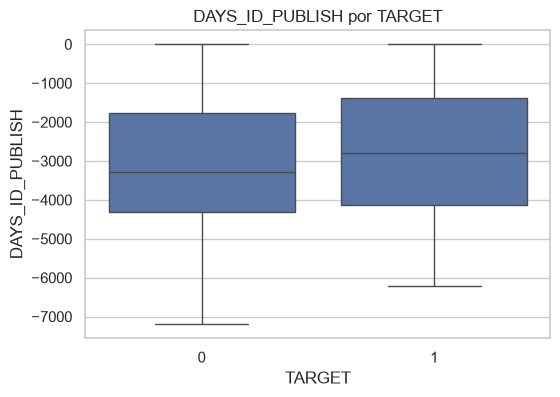

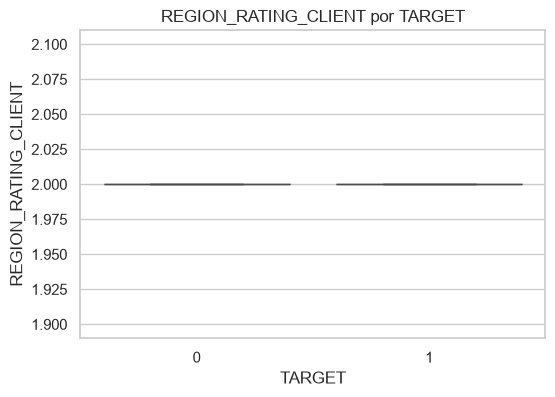

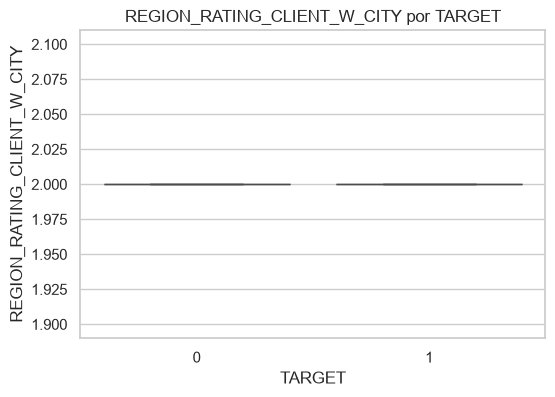

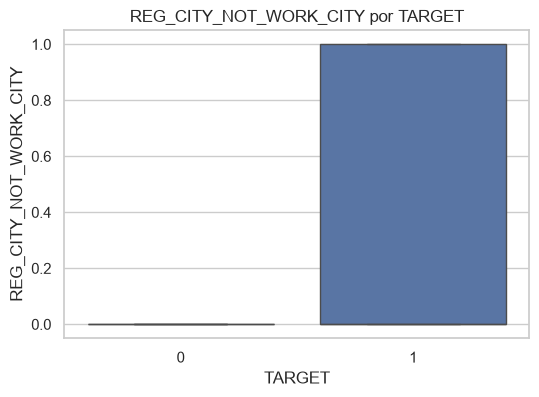

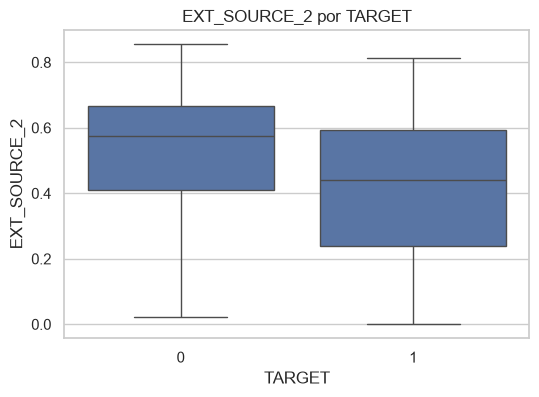

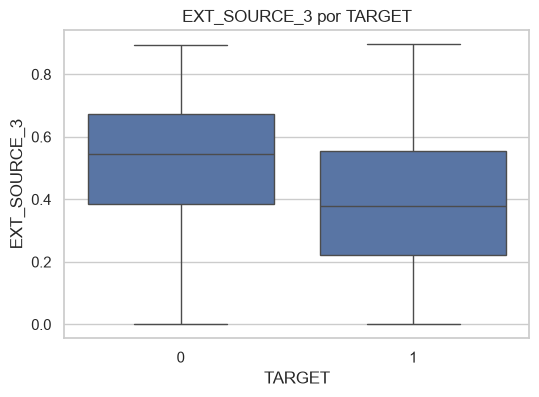

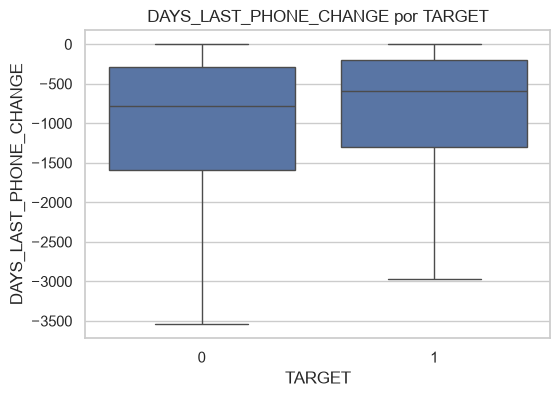

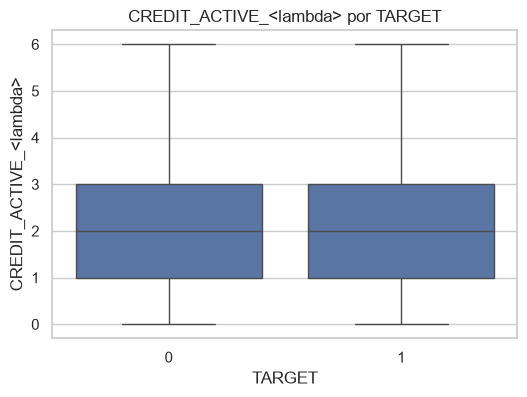

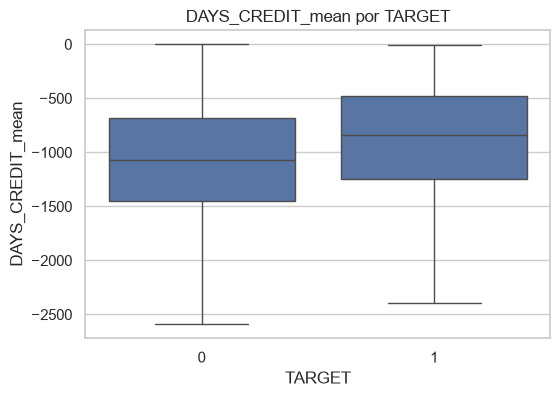

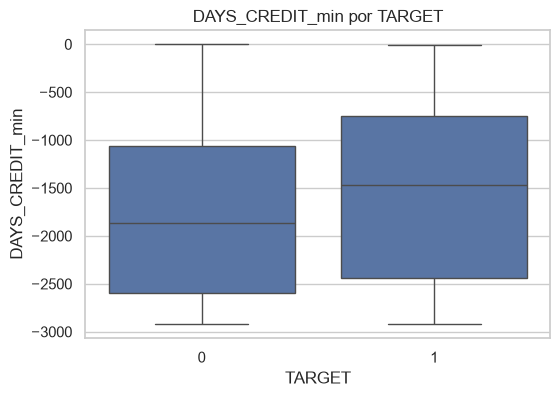

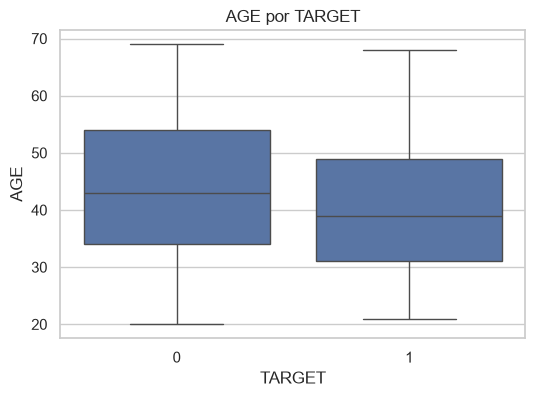

In [39]:
# ============================================
# BOXPLOTS POR TARGET - Variables Predictoras
# ============================================

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,4)

# Selección de numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "TARGET"]

# Filtrar por correlación con TARGET y missing
corrs = df[num_cols].corrwith(df["TARGET"]).abs()
missing = df[num_cols].isna().mean()

predictoras = corrs[(corrs >= 0.05) & (missing <= 0.4)].index.tolist()
print(f"Variables numéricas candidatas: {len(predictoras)}")
print(predictoras)

# Graficar boxplots por TARGET
for col in predictoras:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="TARGET", y=col, data=df, showfliers=False)
    plt.title(f"{col} por TARGET")
    plt.show()


Se observa que las variables AGE, EXT_SOURCE_2, EXT_SOURCE_3, DAYS_CREDIT_mean podrían ser tentativamente buenas predictoras dado
que tienen diferente comportamiento según el TARGET (DEFAULT)

## Variables categoricas

In [40]:
def plot_loan_percentage(feature, df=df, rotation=0, figsize=(12, 5)):
    # Definir colores fijos
    colors = {"No Default": "#1f77b4", "Default": "#d62728"}

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ================================
    # 1. Distribución de categorías
    # ================================
    counts = df[feature].value_counts(normalize=True) * 100
    sns.barplot(x=counts.index, y=counts.values, ax=axes[0], color=colors["No Default"])
    axes[0].set_title(f'Distribución de {feature}', fontsize=10)
    axes[0].set_ylabel('% del total')
    axes[0].set_xlabel(feature)
    axes[0].tick_params(axis='x', rotation=rotation)

    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=8)

    # ================================
    # 2. Gráfico apilado (% Default vs No Default)
    # ================================
    loan_percentage = df.groupby([feature, 'TARGET']).size().unstack(fill_value=0)
    loan_percentage = loan_percentage.div(loan_percentage.sum(axis=1), axis=0) * 100

    # Renombrar columnas (asumiendo 0=No Default, 1=Default)
    loan_percentage = loan_percentage.rename(columns={0: 'No Default', 1: 'Default'})
    loan_percentage = loan_percentage[['No Default','Default']].sort_values(by='No Default', ascending=False)

    loan_percentage.plot(
        kind='bar', stacked=True, ax=axes[1], color=[colors["No Default"], colors["Default"]], legend=False
    )

    axes[1].set_title(f'% Default vs No Default por {feature}', fontsize=10)
    axes[1].set_ylabel('%')
    axes[1].set_xlabel(feature)
    axes[1].tick_params(axis='x', rotation=rotation)

    for p in axes[1].patches:
        height = p.get_height()
        if height > 0:
            axes[1].text(
                p.get_x() + p.get_width() / 2,
                p.get_y() + height / 2,
                f"{height:.1f}%",
                ha='center', va='center', fontsize=7, color='white'
            )

    # Leyenda fija
    axes[1].legend(title='Estatus Préstamo', labels=["No Default", "Default"],
                   bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

    plt.tight_layout()
    plt.show()


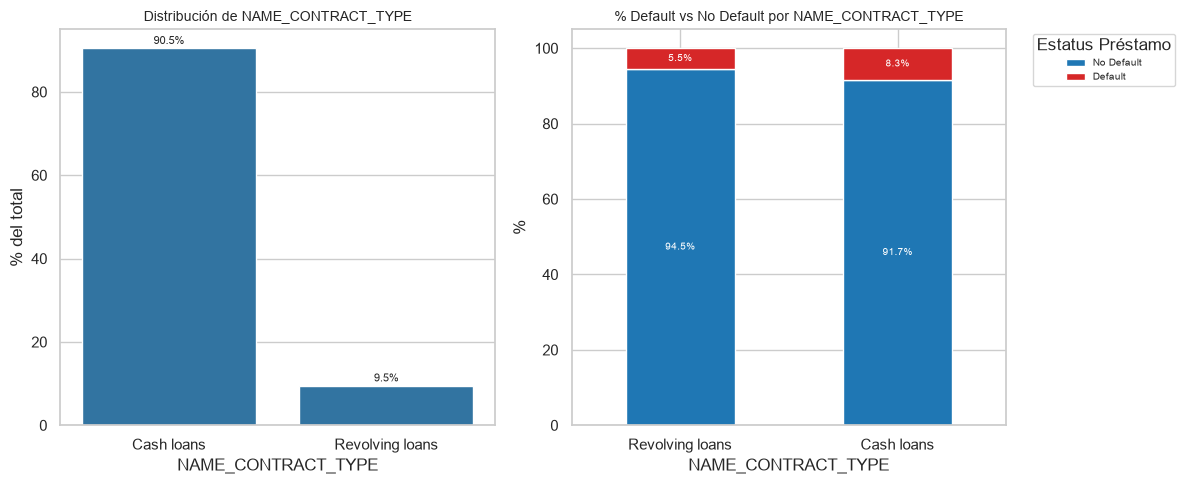

In [41]:
plot_loan_percentage('NAME_CONTRACT_TYPE')

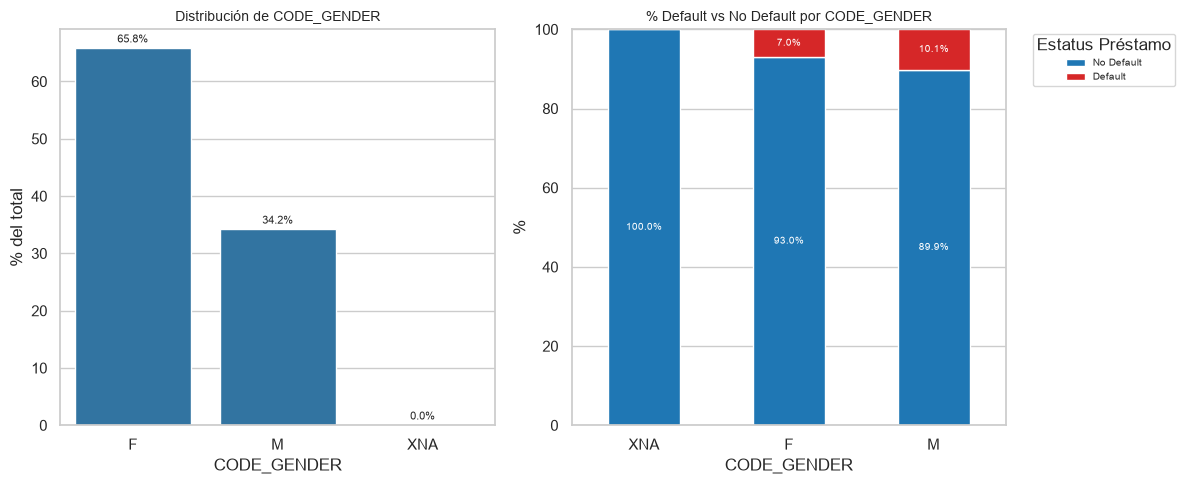

In [42]:
plot_loan_percentage('CODE_GENDER')

valor irrelevante «XNA», se eliminará durante la limpieza

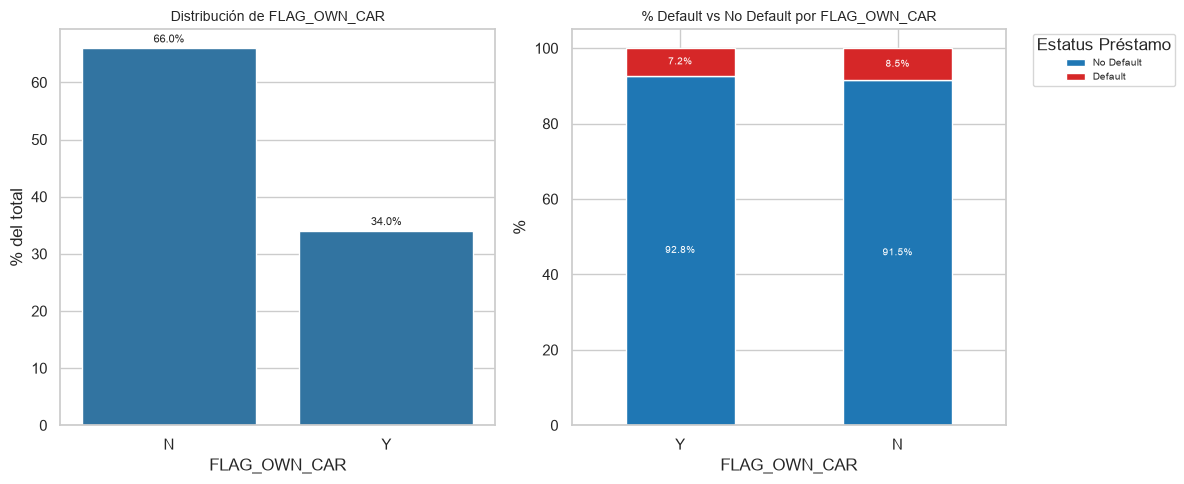

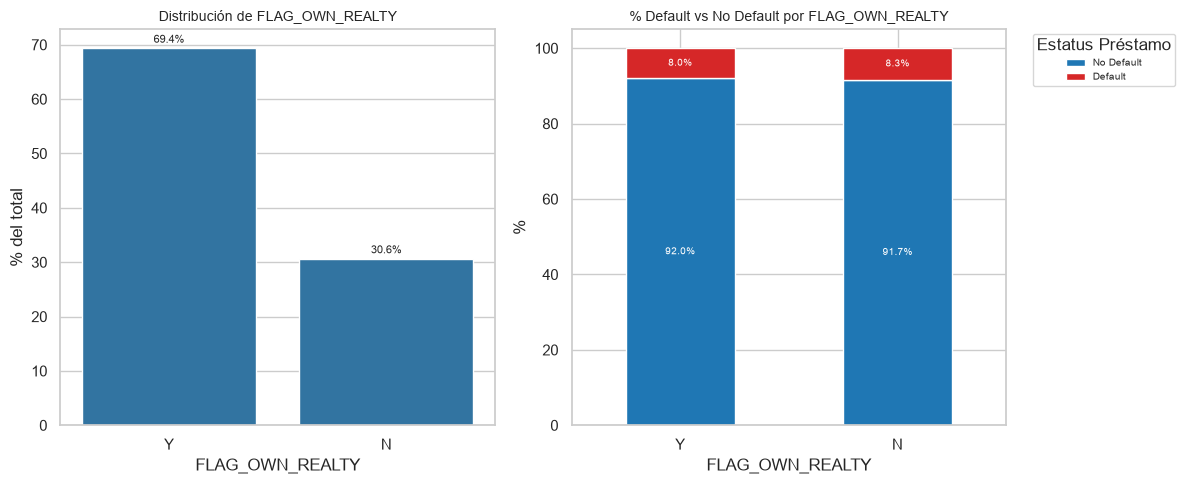

(None, None)

In [43]:
# purpose of the loan
plot_loan_percentage('FLAG_OWN_CAR'),plot_loan_percentage('FLAG_OWN_REALTY')

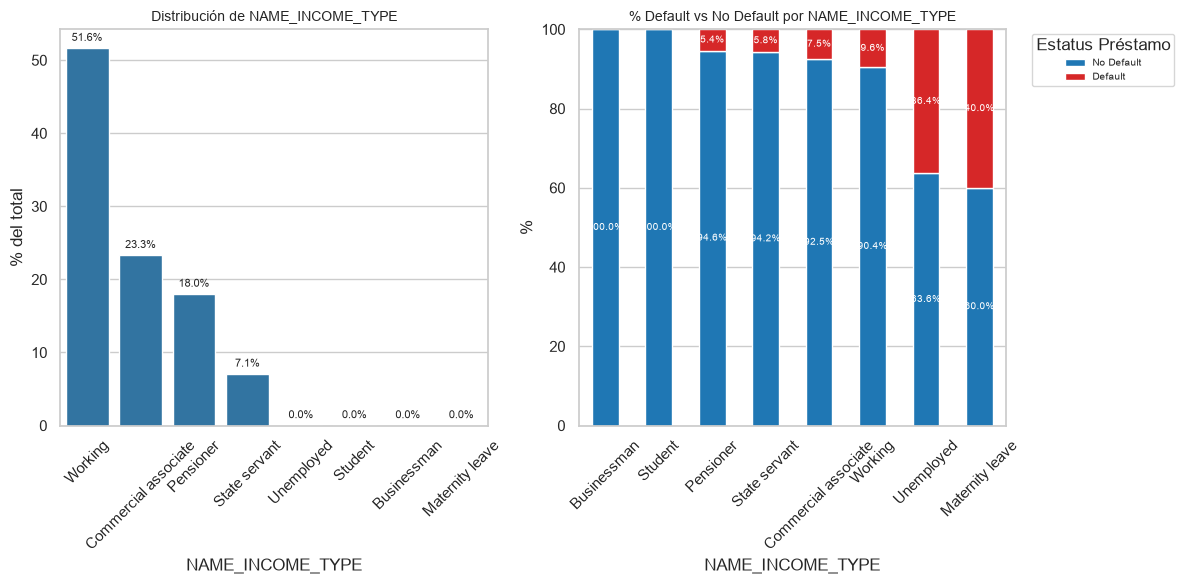

In [44]:
plot_loan_percentage('NAME_INCOME_TYPE', rotation=45, figsize=(12,6))

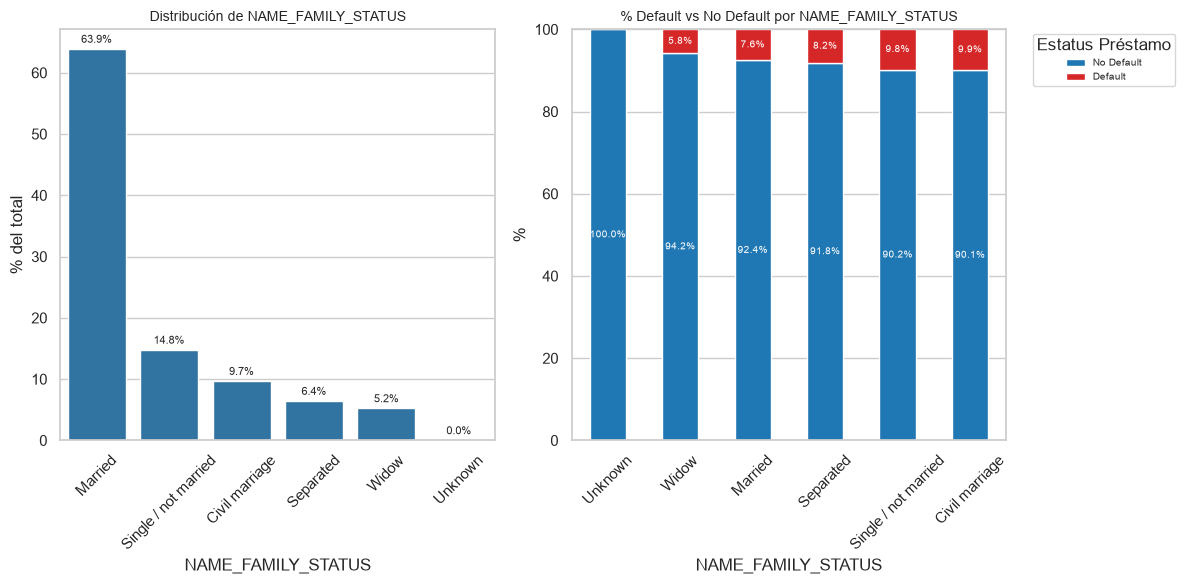

In [45]:
plot_loan_percentage('NAME_FAMILY_STATUS', rotation=45, figsize=(12,6))

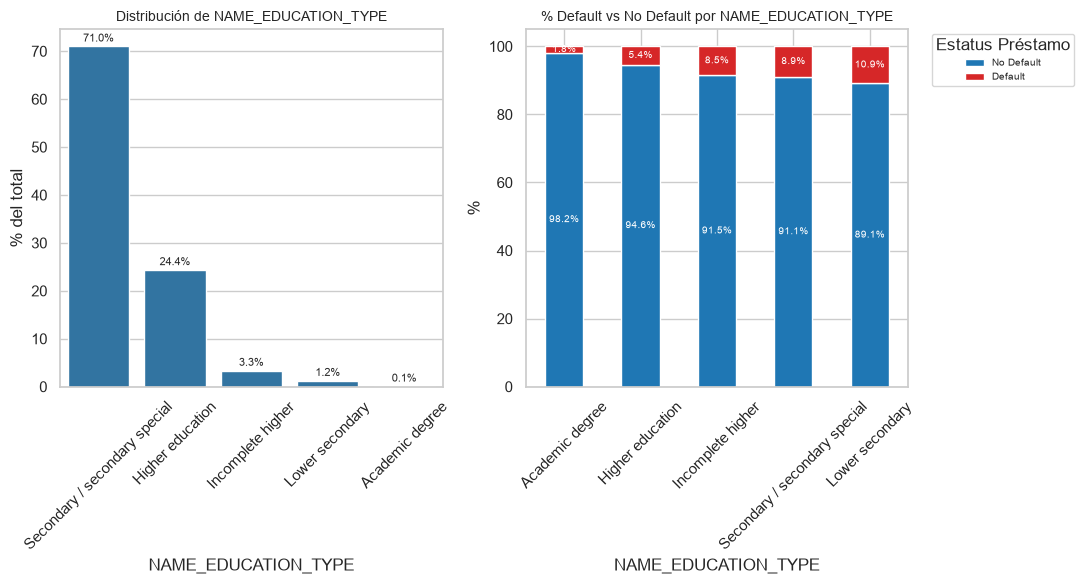

In [46]:
plot_loan_percentage('NAME_EDUCATION_TYPE', rotation=45, figsize=(11,6))

In [47]:
# Ver cuántos registros tienen CODE_GENDER = 'XNA'
print("Registros con CODE_GENDER = 'XNA':", (df["CODE_GENDER"] == "XNA").sum())

# Eliminar registros con XNA
df = df[df["CODE_GENDER"] != "XNA"]

# Verificar limpieza
print("Valores únicos en CODE_GENDER:", df["CODE_GENDER"].unique())
print("Tamaño del dataset después de limpieza:", df.shape)


Registros con CODE_GENDER = 'XNA': 4
Valores únicos en CODE_GENDER: <StringArray>
['M', 'F']
Length: 2, dtype: str
Tamaño del dataset después de limpieza: (306847, 152)


In [48]:
# Calcular porcentaje de missing por columna
missing_percent = df.isnull().mean() * 100

# Identificar columnas con más de 10% de missing
cols_to_drop = missing_percent[missing_percent > 10].index

print("Columnas eliminadas:", list(cols_to_drop))

# Eliminar las columnas del DataFrame
df = df.drop(columns=cols_to_drop)
df.shape

Columnas eliminadas: ['OWN_CAR_AGE', 'OCCUPATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOT

(306847, 79)

In [49]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT_x', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE',
       'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL',
       'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START',
       'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION',
       'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
       'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
       'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_2',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'OBS_60_CNT_SOCIAL_CIRCLE', 

# Modelos de default (Iteración 1)

In [50]:
features = [
    "AGE",  # recuerda que viene de DAYS_BIRTH * -1 / 365
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "NAME_INCOME_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_EDUCATION_TYPE"
]

X = df[features]
y = df["TARGET"]


In [51]:
# Variables categóricas y numéricas
cat_features = ["NAME_CONTRACT_TYPE", "CODE_GENDER", "FLAG_OWN_CAR",
                "NAME_INCOME_TYPE", "NAME_FAMILY_STATUS", "NAME_EDUCATION_TYPE"]
num_features = ["AGE"]

# Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features)
    ]
)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [52]:
# ============ Modelo 1: Logistic Regression ============
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
log_reg.fit(X_train, y_train)

y_pred_prob_lr = log_reg.predict_proba(X_test)[:,1]
print("Logistic Regression AUC:", roc_auc_score(y_test, y_pred_prob_lr))

# ============ Modelo 2: Random Forest ============
rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight="balanced"))
])
rf.fit(X_train, y_train)

y_pred_prob_rf = rf.predict_proba(X_test)[:,1]
print("Random Forest AUC:", roc_auc_score(y_test, y_pred_prob_rf))


Logistic Regression AUC: 0.6348181482557851
Random Forest AUC: 0.6352418496641985


In [53]:
# Métricas de comparación (discriminación, clasificación, calibración)

def ks_stat(y_true, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return np.max(tpr - fpr)

def best_threshold_youden(y_true, y_proba):
    fpr, tpr, thr = roc_curve(y_true, y_proba)
    j = tpr - fpr
    return thr[np.argmax(j)]

def summarize_model(name, y_true, y_proba):
    # Discriminación
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc  = average_precision_score(y_true, y_proba)
    ks      = ks_stat(y_true, y_proba)

    # Calibración
    brier   = brier_score_loss(y_true, y_proba)
    ll      = log_loss(y_true, y_proba, labels=[0,1])

    # Clasificación (usar umbral óptimo por Youden J)
    thr = best_threshold_youden(y_true, y_proba)
    y_pred = (y_proba >= thr).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    report = classification_report(y_true, y_pred, digits=3, output_dict=True)

    summary = {
        "modelo": name,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "KS": ks,
        "RECALL": report['1']['recall'],
        "Brier": brier,
        "LogLoss": ll,
        "Umbral_Youden": thr
    }
    return summary, cm, report

summ_logit, cm_logit, rep_logit = summarize_model("LogisticRegression", y_test, y_pred_prob_lr)
summ_rf,    cm_rf,    rep_rf    = summarize_model("RandomForest", y_test, y_pred_prob_rf)


pd.DataFrame([summ_logit, summ_rf]).sort_values("ROC_AUC", ascending=False)

,modelo,ROC_AUC,PR_AUC,KS,RECALL,Brier,LogLoss,Umbral_Youden
1,RandomForest,0.635242,0.130915,0.199240,0.631593,0.234839,0.661905,0.488445
0,LogisticRegression,0.634818,0.129429,0.202006,0.625000,0.236769,0.665831,0.493386


# SECCIÓN 2: CREACIÓN DE FEATURES CON LLM

# Modelo open-source gratis (TinyLlama) + LangChain

In [54]:
#!pip install -q transformers accelerate langchain langchain-huggingface

import pandas as pd
import json
import re

In [ ]:
# Reinstall and upgrade langchain and langchain-core to fix potential module import issues
#!pip install --upgrade --force-reinstall langchain langchain-core

In [55]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto"
)

hf_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=128,
    do_sample=False,
)

from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate


llm = HuggingFacePipeline(pipeline=hf_pipeline)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 371.06it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


## Prompt para generar las 3 nuevas variables y función

In [56]:
# Prompt
prompt_template = PromptTemplate.from_template("""
Eres un analista de riesgo crediticio en un banco.

A partir del siguiente perfil sociodemográfico del solicitante,
evalúa tres puntajes en una escala de 1 a 5 (solo números enteros):

- STABILITY_INCOME_SCORE:
  Qué tan estables son sus ingresos. 1 = muy estables, 5 = muy inestables.

- FAMILY_RISK_SCORE:
  Qué tan vulnerable es su situación/carga familiar. 1 = bajo riesgo, 5 = alto riesgo.

- FORMALITY_PROFILE_SCORE:
  Qué tan formal es su perfil socioeconómico. 1 = muy informal, 5 = muy formal.

Perfil del cliente:
- Tipo de contrato de crédito: {contract_type}
- Género: {gender}
- Número de hijos: {children}
- Tipo de acompañante / suite: {suite_type}
- Tipo de ingreso: {income_type}
- Nivel educativo: {education_type}
- Estado familiar: {family_status}
- Tipo de vivienda: {housing_type}

Responde EXCLUSIVAMENTE en formato JSON con esta estructura:

{{
  "STABILITY_INCOME_SCORE": <entero 1-5>,
  "FAMILY_RISK_SCORE": <entero 1-5>,
  "FORMALITY_PROFILE_SCORE": <entero 1-5>
}}
""")


# Función para llamar al modelo y parsear el JSON “a mano”
def generar_features_genai(row):
    """
    Dada una fila del DataFrame:
    1) construye el prompt con sus variables,
    2) llama al modelo TinyLlama vía LangChain,
    3) intenta parsear el JSON,
    4) si falla, devuelve valores por defecto (3,3,3).
    """
    prompt = prompt_template.format(
        contract_type  = row.get("NAME_CONTRACT_TYPE", "Unknown"),
        gender         = row.get("CODE_GENDER", "Unknown"),
        children       = int(row.get("CNT_CHILDREN", 0)),
        suite_type     = row.get("NAME_TYPE_SUITE", "Unknown"),
        income_type    = row.get("NAME_INCOME_TYPE", "Unknown"),
        education_type = row.get("NAME_EDUCATION_TYPE", "Unknown"),
        family_status  = row.get("NAME_FAMILY_STATUS", "Unknown"),
        housing_type   = row.get("NAME_HOUSING_TYPE", "Unknown"),
    )

    # 1) Llamada al modelo (HuggingFacePipeline devuelve string)
    raw_output = llm.invoke(prompt)
    text = raw_output if isinstance(raw_output, str) else str(raw_output)

    # 2) Intentar extraer el JSON con una regex (primer bloque {...})
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        # Si no encontramos JSON, devolvemos valores neutros
        return {
            "STABILITY_INCOME_SCORE": 3,
            "FAMILY_RISK_SCORE": 3,
            "FORMALITY_PROFILE_SCORE": 3
        }

    json_str = match.group(0)

    # 3) Parsear JSON
    try:
        df = json.loads(json_str)
    except Exception:
        df = {}

    # 4) Asegurar que todas las claves existan, con fallback a 3
    return {
        "STABILITY_INCOME_SCORE": int(df.get("STABILITY_INCOME_SCORE", 3)),
        "FAMILY_RISK_SCORE": int(df.get("FAMILY_RISK_SCORE", 3)),
        "FORMALITY_PROFILE_SCORE": int(df.get("FORMALITY_PROFILE_SCORE", 3)),
    }


## Prueba en una muestra (para que no se demore)

In [57]:
%%time
# Usar una muestra pequeña en clase
df_sample = df.sample(n=50, random_state=42).copy()

features_genai = df_sample.apply(
    lambda row: pd.Series(generar_features_genai(row)),
    axis=1
)

df_sample_gen = pd.concat(
    [df_sample.reset_index(drop=True),
     features_genai.reset_index(drop=True)],
    axis=1
)

df_sample_gen.head()


[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer LlamaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=128) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for m

CPU times: total: 1h 43min 20s
Wall time: 18min 26s


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,SK_ID_PREV_x,NAME_CONTRACT_STATUS,AMT_APPLICATION,AMT_CREDIT_y,INST_CNT,INST_PAY_DIFF_MEAN,INST_PAY_DIFF_MIN,INST_PAY_DIFF_MAX,INST_DELAY_MEAN,INST_DELAY_MAX,INST_TOTAL_PAID,INST_TOTAL_DUE,SK_ID_PREV_y,SK_DPD_x,AGE,STABILITY_INCOME_SCORE,FAMILY_RISK_SCORE,FORMALITY_PROFILE_SCORE
0,186534,0,Cash loans,M,Y,Y,0,157500.0,171000.0,11263.5,171000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Civil marriage,House / apartment,0.018209,-225,-1606.0,-4291,1,1,0,1,0,0,2.0,3,3,THURSDAY,6,0,1,1,0,1,1,Business Entity Type 3,0.142946,1.0,0.0,1.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,19215.000000,18085.500000,7.0,-1308.477857,-2922.615,0.0,5.571429,25.0,22320.405,31479.750,1.0,0.0,44,3,3,3
1,375559,0,Cash loans,F,N,Y,1,90000.0,380533.5,16893.0,328500.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.008575,-3115,-3100.0,-3100,1,1,0,1,0,0,3.0,2,2,WEDNESDAY,10,0,0,0,0,1,1,Self-employed,0.590150,5.0,0.0,5.0,0.0,-1198.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5.0,3.0,63535.500000,153137.700000,46.0,-622.488913,-9982.035,0.0,16.739130,893.0,423857.835,452492.325,2.0,1.0,44,3,3,3
2,238316,0,Cash loans,F,N,N,0,130500.0,1078200.0,34780.5,900000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.010006,-5250,-2188.0,-3012,1,1,1,1,1,0,2.0,2,1,MONDAY,10,0,0,0,0,0,0,Kindergarten,0.599562,1.0,1.0,1.0,1.0,-1128.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14.0,4.0,369645.107143,436523.142857,51.0,-411.813529,-10350.000,0.0,-10.019608,12.0,1735491.465,1756493.955,3.0,0.0,35,3,3,3
3,206793,0,Cash loans,F,N,N,0,81000.0,254700.0,14350.5,225000.0,Family,Pensioner,Secondary / secondary special,Widow,House / apartment,0.006852,365243,-14290.0,-4483,1,0,0,1,0,0,1.0,3,3,THURSDAY,6,0,0,0,0,0,0,XNA,0.103914,0.0,0.0,0.0,0.0,-545.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8.0,7.0,74709.562500,80540.437500,80.0,-384.044625,-10748.745,0.0,-12.512500,5.0,763651.980,794375.550,7.0,0.0,65,3,3,3
4,338197,0,Cash loans,F,N,Y,1,315000.0,582804.0,24822.0,463500.0,Unaccompanied,Commercial associate,Secondary / secondary special,Civil marriage,House / apartment,0.024610,-533,-1023.0,-4918,1,1,0,1,0,1,3.0,2,2,SATURDAY,15,0,0,0,1,1,0,Self-employed,0.579222,0.0,0.0,0.0,0.0,-1004.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,900000.000000,978408.000000,3.0,0.000000,0.000,0.0,-16.000000,-1.0,1074469.680,1074469.680,1.0,0.0,42,3,3,3


In [58]:
# ¿Qué se observa?
df_sample_gen

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,SK_ID_PREV_x,NAME_CONTRACT_STATUS,AMT_APPLICATION,AMT_CREDIT_y,INST_CNT,INST_PAY_DIFF_MEAN,INST_PAY_DIFF_MIN,INST_PAY_DIFF_MAX,INST_DELAY_MEAN,INST_DELAY_MAX,INST_TOTAL_PAID,INST_TOTAL_DUE,SK_ID_PREV_y,SK_DPD_x,AGE,STABILITY_INCOME_SCORE,FAMILY_RISK_SCORE,FORMALITY_PROFILE_SCORE
0,186534,0,Cash loans,M,Y,Y,0,157500.0,171000.0,11263.5,171000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Civil marriage,House / apartment,0.018209,-225,-1606.0,-4291,1,1,0,1,0,0,2.0,3,3,THURSDAY,6,0,1,1,0,1,1,Business Entity Type 3,0.142946,1.0,0.0,1.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,19215.000000,18085.500000,7.0,-1308.477857,-2922.615,0.000,5.571429,25.0,22320.405,31479.750,1.0,0.0,44,3,3,3
1,375559,0,Cash loans,F,N,Y,1,90000.0,380533.5,16893.0,328500.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.008575,-3115,-3100.0,-3100,1,1,0,1,0,0,3.0,2,2,WEDNESDAY,10,0,0,0,0,1,1,Self-employed,0.590150,5.0,0.0,5.0,0.0,-1198.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5.0,3.0,63535.500000,153137.700000,46.0,-622.488913,-9982.035,0.000,16.739130,893.0,423857.835,452492.325,2.0,1.0,44,3,3,3
2,238316,0,Cash loans,F,N,N,0,130500.0,1078200.0,34780.5,900000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.010006,-5250,-2188.0,-3012,1,1,1,1,1,0,2.0,2,1,MONDAY,10,0,0,0,0,0,0,Kindergarten,0.599562,1.0,1.0,1.0,1.0,-1128.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14.0,4.0,369645.107143,436523.142857,51.0,-411.813529,-10350.000,0.000,-10.019608,12.0,1735491.465,1756493.955,3.0,0.0,35,3,3,3
3,206793,0,Cash loans,F,N,N,0,81000.0,254700.0,14350.5,225000.0,Family,Pensioner,Secondary / secondary special,Widow,House / apartment,0.006852,365243,-14290.0,-4483,1,0,0,1,0,0,1.0,3,3,THURSDAY,6,0,0,0,0,0,0,XNA,0.103914,0.0,0.0,0.0,0.0,-545.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8.0,7.0,74709.562500,80540.437500,80.0,-384.044625,-10748.745,0.000,-12.512500,5.0,763651.980,794375.550,7.0,0.0,65,3,3,3
4,338197,0,Cash loans,F,N,Y,1,315000.0,582804.0,24822.0,463500.0,Unaccompanied,Commercial associate,Secondary / secondary special,Civil marriage,House / apartment,0.024610,-533,-1023.0,-4918,1,1,0,1,0,1,3.0,2,2,SATURDAY,15,0,0,0,1,1,0,Self-employed,0.579222,0.0,0.0,0.0,0.0,-1004.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,900000.000000,978408.000000,3.0,0.000000,0.000,0.000,-16.000000,-1.0,1074469.680,1074469.680,1.0,0.0,42,3,3,3
5,239613,0,Cash loans,F,N,N,1,67500.0,270000.0,12640.5,270000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.004849,-706,-8444.0,-429,1,1,0,1,0,0,3.0,2,2,TUESDAY,16,0,0,0,0,0,0,Business Entity Type 3,0.051603,1.0,0.0,1.0,0.0,-2.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,4.0,2.0,28113.750000,28003.500000,20.0,-718.557750,-4797.000,0.000,-4.350000,51.0,114929.190,129300.345,2.0,2.0,27,3,3,

## Evaluando factibilidad

In [59]:
# identificación de posibles combinaciones

cols_prompt = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "CNT_CHILDREN",         # o CNT_CHILDREN_BIN si ya lo bindeaste
    "NAME_TYPE_SUITE",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE"
]

# Opcional: rellenar nulos para no tener combinaciones con NaN
df[cols_prompt] = df[cols_prompt].fillna("Unknown")

# Tabla de combinaciones únicas
combos_unique = df[cols_prompt].drop_duplicates().reset_index(drop=True)

print("Número total de registros:", len(df))
print("Número de combinaciones únicas usadas en el prompt:", len(combos_unique))

combos_unique.head()


Número total de registros: 306847
Número de combinaciones únicas usadas en el prompt: 6758


,NAME_CONTRACT_TYPE,CODE_GENDER,CNT_CHILDREN,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE
0,Cash loans,M,0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment
1,Cash loans,F,0,Family,State servant,Higher education,Married,House / apartment
2,Revolving loans,M,0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment
3,Cash loans,F,0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment
4,Cash loans,M,0,"Spouse, partner",State servant,Secondary / secondary special,Married,House / apartment


In [60]:
# Tiempo en horas que demoraria si es que usamos este modelo
6758/50 * 4 / 60

9.010666666666667

In [61]:
print("NAME_CONTRACT_TYPE",df["NAME_CONTRACT_TYPE"].unique())
print("CODE_GENDER",df["CODE_GENDER"].unique())
print("CNT_CHILDREN",df["CNT_CHILDREN"].unique())
print("NAME_TYPE_SUITE",df["NAME_TYPE_SUITE"].unique())
print("NAME_INCOME_TYPE",df["NAME_INCOME_TYPE"].unique())
print("NAME_EDUCATION_TYPE",df["NAME_EDUCATION_TYPE"].unique())
print("NAME_FAMILY_STATUS",df["NAME_FAMILY_STATUS"].unique())
print("NAME_HOUSING_TYPE",df["NAME_HOUSING_TYPE"].unique())



NAME_CONTRACT_TYPE <StringArray>
['Cash loans', 'Revolving loans']
Length: 2, dtype: str
CODE_GENDER <StringArray>
['M', 'F']
Length: 2, dtype: str
CNT_CHILDREN [ 0  1  2  3  4  7  5  6  8  9 11 12 10 19 14]
NAME_TYPE_SUITE <StringArray>
[  'Unaccompanied',          'Family', 'Spouse, partner',        'Children',
         'Other_A',         'Unknown',         'Other_B', 'Group of people']
Length: 8, dtype: str
NAME_INCOME_TYPE <StringArray>
[             'Working',        'State servant', 'Commercial associate',
            'Pensioner',           'Unemployed',              'Student',
          'Businessman',      'Maternity leave']
Length: 8, dtype: str
NAME_EDUCATION_TYPE <StringArray>
['Secondary / secondary special',              'Higher education',
             'Incomplete higher',               'Lower secondary',
               'Academic degree']
Length: 5, dtype: str
NAME_FAMILY_STATUS <StringArray>
['Single / not married',              'Married',       'Civil marriage',
        

In [62]:
df["CNT_CHILDREN_BIN"] = pd.cut(
    df["CNT_CHILDREN"],
    bins=[-1, 0, 2, 20],          # 0 / 1–2 / 3+
    labels=["0", "1-2", "3+"]
)

# Modelo gemini-2.5-flash

In [63]:
from dotenv import load_dotenv

# Load the .env file
load_dotenv()

google_api_key = os.getenv("GOOGLE_API_KEY")

In [64]:
cols_prompt_core = [
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "CNT_CHILDREN_BIN"
]

In [65]:
# Evaluando si tienen missing las columnas
missing = (df[cols_prompt_core].isna().sum() / len(df[cols_prompt_core]) * 100).sort_values(ascending=True).head(30)
print("missing %:")
print(missing.round(3).to_string())

missing %:
NAME_INCOME_TYPE       0.0
NAME_EDUCATION_TYPE    0.0
NAME_FAMILY_STATUS     0.0
NAME_HOUSING_TYPE      0.0
CNT_CHILDREN_BIN       0.0


In [66]:
combos_core = df[cols_prompt_core].drop_duplicates().reset_index(drop=True)

print("Registros totales:", len(df))
print("Combinaciones núcleo:", len(combos_core))

combos_core.head()

Registros totales: 306847
Combinaciones núcleo: 954


,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,CNT_CHILDREN_BIN
0,Working,Secondary / secondary special,Single / not married,House / apartment,0
1,State servant,Higher education,Married,House / apartment,0
2,Working,Secondary / secondary special,Civil marriage,House / apartment,0
3,State servant,Secondary / secondary special,Married,House / apartment,0
4,Commercial associate,Higher education,Married,House / apartment,1-2


## Conexión y prompt

In [ ]:
#!pip install -q langchain google-generativeai

In [69]:
import os
import getpass
import json
import math
import numpy as np
import pandas as pd
from tqdm import tqdm

# LangChain solo para manejo de prompts
from langchain_core.prompts import PromptTemplate

# Gemini SDK oficial
import google.generativeai as genai


In [ ]:
# Ingresa el API key
#os.environ["GOOGLE_API_KEY"]: str = getpass.getpass("Ingresa tu Google AI API key: ")

In [70]:
genai.configure(api_key=os.environ["GOOGLE_API_KEY"])

model = genai.GenerativeModel("gemini-2.5-flash")

In [71]:
# Prompt con LangChain (PromptTemplate) para el batch
prompt_template = PromptTemplate.from_template("""
Eres un analista de riesgo crediticio en un banco.

Te daré una lista de clientes numerados del 1 al {n_clientes} con su perfil socioeconómico.

Para cada cliente, evalúa tres puntajes (enteros 1 a 5):

- STABILITY_INCOME_SCORE: qué tan estables son sus ingresos.
- FAMILY_RISK_SCORE: qué tan vulnerable es su situación/carga familiar.
- FORMALITY_PROFILE_SCORE: qué tan formal es su perfil socioeconómico.

Clientes:
{clientes_descripcion}

Responde EXCLUSIVAMENTE en formato JSON con la siguiente estructura:

{{
  "1": {{"STABILITY_INCOME_SCORE": <1-5>, "FAMILY_RISK_SCORE": <1-5>, "FORMALITY_PROFILE_SCORE": <1-5>}},
  "2": {{...}},
  ...
}}
""")


In [72]:
import textwrap

def build_batch_prompt(df_batch: pd.DataFrame) -> str:
    lineas = []
    for i, row in df_batch.reset_index(drop=True).iterrows():
        idx = i + 1
        lineas.append(
            f'{idx}) ingreso="{row["NAME_INCOME_TYPE"]}", '
            f'educacion="{row["NAME_EDUCATION_TYPE"]}", '
            f'estado_familiar="{row["NAME_FAMILY_STATUS"]}", '
            f'vivienda="{row["NAME_HOUSING_TYPE"]}", '
            f'hijos_grupo="{row["CNT_CHILDREN_BIN"]}"'
        )
    clientes_txt = "\n".join(lineas)

    prompt = prompt_template.format(
        n_clientes=len(df_batch),
        clientes_descripcion=clientes_txt
    )

    return textwrap.dedent(prompt).strip()


## Prueba en una muestra

In [73]:
# Prueba

import json

# 1) Definir tamaño de batch para la prueba
batch_size = 10   # 70 o 10 si quieres algo más pequeño primero

# 2) Tomar SOLO el primer batch
df_batch_test = combos_core.reset_index(drop=True).iloc[:batch_size]
print("Filas en batch de prueba:", len(df_batch_test))

# 3) Construir el prompt y verlo
prompt_test = build_batch_prompt(df_batch_test)
print("===== PROMPT DE PRUEBA =====")
print(prompt_test)

# 4) Llamar a Gemini SOLO para este batch
resp = model.generate_content(prompt_test)
text = resp.text
print("\n===== TEXTO DEVUELTO POR GEMINI =====")
print(text)

# 5) Intentar extraer y parsear el JSON
start = text.find("{")
end = text.rfind("}")
if start == -1 or end == -1:
    print("\n⚠️ No se encontró JSON en la respuesta.")
    scores_dict = {}
else:
    json_str = text[start:end+1]
    print("\n===== JSON EXTRAÍDO =====")
    print(json_str)

    try:
        scores_dict = json.loads(json_str)
    except Exception as e:
        print("\n❌ Error al hacer json.loads:", e)
        scores_dict = {}

# 6) Mapear los scores a un DataFrame de prueba
result_rows_test = []
df_batch_reset = df_batch_test.reset_index(drop=True)

for i, row in df_batch_reset.iterrows():
    idx = str(i + 1)
    s = scores_dict.get(idx, {})

    result_rows_test.append({
        "NAME_INCOME_TYPE": row["NAME_INCOME_TYPE"],
        "NAME_EDUCATION_TYPE": row["NAME_EDUCATION_TYPE"],
        "NAME_FAMILY_STATUS": row["NAME_FAMILY_STATUS"],
        "NAME_HOUSING_TYPE": row["NAME_HOUSING_TYPE"],
        "CNT_CHILDREN_BIN": row["CNT_CHILDREN_BIN"],
        "STABILITY_INCOME_SCORE": int(s.get("STABILITY_INCOME_SCORE", 3)),
        "FAMILY_RISK_SCORE": int(s.get("FAMILY_RISK_SCORE", 3)),
        "FORMALITY_PROFILE_SCORE": int(s.get("FORMALITY_PROFILE_SCORE", 3)),
    })

df_scores_test = pd.DataFrame(result_rows_test)
print("\n===== SCORES DE PRUEBA =====")
df_scores_test.head()


Filas en batch de prueba: 10
===== PROMPT DE PRUEBA =====
Eres un analista de riesgo crediticio en un banco.

Te daré una lista de clientes numerados del 1 al 10 con su perfil socioeconómico.

Para cada cliente, evalúa tres puntajes (enteros 1 a 5):

- STABILITY_INCOME_SCORE: qué tan estables son sus ingresos.
- FAMILY_RISK_SCORE: qué tan vulnerable es su situación/carga familiar.
- FORMALITY_PROFILE_SCORE: qué tan formal es su perfil socioeconómico.

Clientes:
1) ingreso="Working", educacion="Secondary / secondary special", estado_familiar="Single / not married", vivienda="House / apartment", hijos_grupo="0"
2) ingreso="State servant", educacion="Higher education", estado_familiar="Married", vivienda="House / apartment", hijos_grupo="0"
3) ingreso="Working", educacion="Secondary / secondary special", estado_familiar="Civil marriage", vivienda="House / apartment", hijos_grupo="0"
4) ingreso="State servant", educacion="Secondary / secondary special", estado_familiar="Married", vivienda=

,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,CNT_CHILDREN_BIN,STABILITY_INCOME_SCORE,FAMILY_RISK_SCORE,FORMALITY_PROFILE_SCORE
0,Working,Secondary / secondary special,Single / not married,House / apartment,0,3,5,4
1,State servant,Higher education,Married,House / apartment,0,5,4,5
2,Working,Secondary / secondary special,Civil marriage,House / apartment,0,3,4,4
3,State servant,Secondary / secondary special,Married,House / apartment,0,5,4,4
4,Commercial associate,Higher education,Married,House / apartment,1-2,4,3,5


## Generación de scores para todas las combinaciones

Se ejecuto de forma aislada para que no se consuma tantos recursos durante la clase

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# # Loop de batches con Gemini
# %%time
# batch_size = 80
# batches = np.array_split(
#     combos_core.reset_index(drop=True),
#     math.ceil(len(combos_core) / batch_size)
# )

# result_rows = []

# for df_batch in tqdm(batches):
#     prompt = build_batch_prompt(df_batch)

#     # Llamada al modelo Gemini
#     resp = model.generate_content(prompt)
#     text = resp.text

#     # Extraer JSON
#     start = text.find("{")
#     end = text.rfind("}")
#     if start == -1 or end == -1:
#         scores_dict = {}
#     else:
#         json_str = text[start:end+1]
#         try:
#             scores_dict = json.loads(json_str)
#         except Exception:
#             scores_dict = {}

#     # Mapear scores al batch
#     df_batch_reset = df_batch.reset_index(drop=True)
#     for i, row in df_batch_reset.iterrows():
#         idx = str(i + 1)
#         s = scores_dict.get(idx, {})

#         result_rows.append({
#             "NAME_INCOME_TYPE": row["NAME_INCOME_TYPE"],
#             "NAME_EDUCATION_TYPE": row["NAME_EDUCATION_TYPE"],
#             "NAME_FAMILY_STATUS": row["NAME_FAMILY_STATUS"],
#             "NAME_HOUSING_TYPE": row["NAME_HOUSING_TYPE"],
#             "CNT_CHILDREN_BIN": row["CNT_CHILDREN_BIN"],
#             "STABILITY_INCOME_SCORE": int(s.get("STABILITY_INCOME_SCORE", 3)),
#             "FAMILY_RISK_SCORE": int(s.get("FAMILY_RISK_SCORE", 3)),
#             "FORMALITY_PROFILE_SCORE": int(s.get("FORMALITY_PROFILE_SCORE", 3)),
#         })


# df_gen_scores = pd.DataFrame(result_rows)

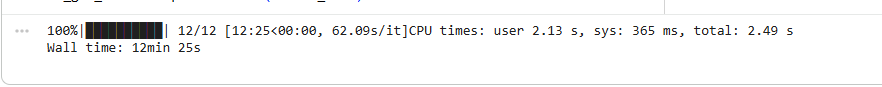

In [ ]:
#df_gen_scores.to_csv("/content/drive/MyDrive/df_gen_scores.csv", index=False) # Guardar directamente en tu Drive (opción 1)

In [ ]:
#df_gen_scores.to_csv("df_gen_scores.csv", index=False) # Guardar y descargar (opción 2)

## Importando base con scores generados

In [75]:
df_gen_scores = pd.read_csv(root_path +"/data/df_gen_scores.csv")
df_gen_scores.head()

,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,CNT_CHILDREN_BIN,STABILITY_INCOME_SCORE,FAMILY_RISK_SCORE,FORMALITY_PROFILE_SCORE
0,Working,Secondary / secondary special,Single / not married,House / apartment,0,3,5,4
1,State servant,Higher education,Married,House / apartment,0,5,4,5
2,Working,Secondary / secondary special,Civil marriage,House / apartment,0,3,4,4
3,State servant,Secondary / secondary special,Married,House / apartment,0,5,4,4
4,Commercial associate,Higher education,Married,House / apartment,1-2,4,3,5


In [76]:
df_gen_scores.shape

(954, 8)

In [77]:
df_gen = df.merge(
    df_gen_scores,
    on=[
        "NAME_INCOME_TYPE",
        "NAME_EDUCATION_TYPE",
        "NAME_FAMILY_STATUS",
        "NAME_HOUSING_TYPE",
        "CNT_CHILDREN_BIN"
    ],
    how="left"
)

df_gen.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,SK_ID_PREV_x,NAME_CONTRACT_STATUS,AMT_APPLICATION,AMT_CREDIT_y,INST_CNT,INST_PAY_DIFF_MEAN,INST_PAY_DIFF_MIN,INST_PAY_DIFF_MAX,INST_DELAY_MEAN,INST_DELAY_MAX,INST_TOTAL_PAID,INST_TOTAL_DUE,SK_ID_PREV_y,SK_DPD_x,AGE,CNT_CHILDREN_BIN,STABILITY_INCOME_SCORE,FAMILY_RISK_SCORE,FORMALITY_PROFILE_SCORE
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-637,-3648.0,-2120,1,1,0,1,1,0,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.262949,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,179055.00,179055.00,19.0,0.000000,0.000,0.0,-20.421053,-12.0,219625.695,219625.695,1.0,0.0,25,0,3,5,4
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-1188,-1186.0,-291,1,1,0,1,1,0,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.622246,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.0,3.0,435436.50,484191.00,25.0,0.000000,0.000,0.0,-7.160000,-1.0,1618864.650,1618864.650,3.0,0.0,45,0,5,4,5
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-225,-4260.0,-2531,1,1,1,1,1,0,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.555912,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,24282.00,20106.00,3.0,0.000000,0.000,0.0,-7.666667,-3.0,21288.465,21288.465,1.0,0.0,52,0,3,5,4
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-3039,-9833.0,-2437,1,1,0,1,0,0,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,0.650442,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9.0,5.0,272203.26,291695.50,16.0,0.000000,0.000,0.0,-19.375000,-1.0,1007153.415,1007153.415,3.0,0.0,52,0,3,4,4
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-3038,-4311.0,-3458,1,1,0,1,0,0,1.0,2,2,THURSDAY,11,0,0,0,0,1,1,Religion,0.322738,0.0,0.0,0.0,0.0,-1106.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,6.0,6.0,150530.25,166638.75,66.0,-452.384318,-22655.655,0.0,-3.636364,12.0,806127.975,835985.340,5.0,0.0,54,0,3,5,4


# SECCIÓN 3: PRED DEFAULT EN BANCA (+ GEN AI)

# Modelos de default (Iteración 2: + variables creadas con LLM)

In [78]:
features = [
    "AGE",  # recuerda que viene de DAYS_BIRTH * -1 / 365
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "STABILITY_INCOME_SCORE",
    "FAMILY_RISK_SCORE",
    "FORMALITY_PROFILE_SCORE"
]

X = df_gen[features]
y = df_gen["TARGET"]

# Variables categóricas y numéricas
cat_features = ["NAME_CONTRACT_TYPE", "CODE_GENDER", "FLAG_OWN_CAR"]
num_features = ["AGE", "STABILITY_INCOME_SCORE", "FAMILY_RISK_SCORE", "FORMALITY_PROFILE_SCORE"]

# Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features)
    ]
)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [79]:
# ============ Modelo 1: Logistic Regression ============
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
log_reg.fit(X_train, y_train)

y_pred_prob_lr = log_reg.predict_proba(X_test)[:,1]
print("Logistic Regression AUC:", roc_auc_score(y_test, y_pred_prob_lr))

# ============ Modelo 2: Random Forest ============
rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight="balanced"))
])
rf.fit(X_train, y_train)

y_pred_prob_rf = rf.predict_proba(X_test)[:,1]
print("Random Forest AUC:", roc_auc_score(y_test, y_pred_prob_rf))

Logistic Regression AUC: 0.6239762045914351
Random Forest AUC: 0.630632957291599


In [80]:
# Metricas en train
y_pred_prob_lr = log_reg.predict_proba(X_train)[:, 1]
summ_logit, cm_logit, rep_logit = summarize_model("LogisticRegression", y_train, y_pred_prob_lr)

y_pred_prob_rf = rf.predict_proba(X_train)[:,1]
summ_rf,    cm_rf,    rep_rf    = summarize_model("RandomForest", y_train, y_pred_prob_rf)

pd.DataFrame([summ_logit, summ_rf]).sort_values("ROC_AUC", ascending=False)

,modelo,ROC_AUC,PR_AUC,KS,RECALL,Brier,LogLoss,Umbral_Youden
1,RandomForest,0.648604,0.134214,0.219100,0.612479,0.234154,0.660096,0.503956
0,LogisticRegression,0.624586,0.120272,0.185907,0.554697,0.238523,0.670048,0.511398


In [81]:
# Metricas en test
y_pred_prob_lr = log_reg.predict_proba(X_test)[:, 1]
summ_logit, cm_logit, rep_logit = summarize_model("LogisticRegression", y_test, y_pred_prob_lr)

y_pred_prob_rf = rf.predict_proba(X_test)[:,1]
summ_rf,    cm_rf,    rep_rf    = summarize_model("RandomForest", y_test, y_pred_prob_rf)

pd.DataFrame([summ_logit, summ_rf]).sort_values("ROC_AUC", ascending=False)

,modelo,ROC_AUC,PR_AUC,KS,RECALL,Brier,LogLoss,Umbral_Youden
1,RandomForest,0.630633,0.126170,0.194678,0.537540,0.235625,0.663172,0.523077
0,LogisticRegression,0.623976,0.122204,0.184217,0.654467,0.238899,0.670795,0.483855
